# **1. Multi-class Weather Dataset**
[Multi-class Weather Dataset](https://www.kaggle.com/datasets/pratik2901/multiclass-weather-datase)은 다양한 기상 조건을 포함하는 이미지 데이터셋으로, 주로 기계 학습 및 딥러닝 모델을 학습하거나 평가하는 데 사용됩니다. 이 데이터셋은 맑음, 비, 눈, 흐림과 같은 여러 날씨 유형으로 라벨이 지정된 다중 클래스 분류 문제를 다룹니다. 각 클래스는 다양한 시간대, 계절, 지역에서 촬영된 이미지를 포함하여 현실 세계의 다양성을 반영하도록 설계되었습니다. 이를 통해 모델은 날씨 조건을 정확히 분류하고, 기상 관측, 자동화된 날씨 보고, 혹은 자율주행 차량의 환경 인식 시스템과 같은 다양한 응용 분야에서 활용될 수 있습니다.

In [1]:
from google.colab import files
files.upload()  # kaggle.json 업로드 창 표시

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [2]:
!kaggle datasets download pratik2901/multiclass-weather-dataset

Dataset URL: https://www.kaggle.com/datasets/pratik2901/multiclass-weather-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/91.4M [00:00<?, ?B/s]
100% 91.4M/91.4M [00:00<00:00, 1.29GB/s]


In [3]:
import os
import zipfile
import random
from shutil import copyfile, rmtree

In [4]:
zip_file = 'multiclass-weather-dataset.zip'
base_dir = './Multi-class Weather Dataset'
train_dir = './train'
test_dir = './test'

In [5]:
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('.')

In [6]:
categories = ['Cloudy', 'Rain', 'Shine', 'Sunrise']

In [7]:
if os.path.exists(train_dir):
    rmtree(train_dir)
if os.path.exists(test_dir):
    rmtree(test_dir)

In [8]:
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

In [9]:
for category in categories:
    os.makedirs(os.path.join(train_dir, category), exist_ok=True)
    os.makedirs(os.path.join(test_dir, category), exist_ok=True)

In [10]:
for category in categories:
    category_path = os.path.join(base_dir, category)
    # print(category_path)
    files = os.listdir(category_path)
    # print(files)
    random.shuffle(files)

    split_idx = int(len(files) * 0.8)
    train_files = files[:split_idx]
    test_files = files[split_idx:]

    for file in train_files:
        src = os.path.join(category_path, file)
        dst = os.path.join(train_dir, category, file)
        copyfile(src, dst)

    for file in test_files:
        src = os.path.join(category_path, file)
        dst = os.path.join(test_dir, category, file)
        copyfile(src, dst)

print('데이터 분리가 완료되었습니다')

데이터 분리가 완료되었습니다


In [11]:
import torch
import time
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.datasets as datasets
from torchvision.utils import make_grid
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import matplotlib.image as image
import numpy as np

In [12]:
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [13]:
transform_test = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [14]:
train_dataset = datasets.ImageFolder(
    root = 'train/',
    transform=transform_train
)

In [15]:
dataset_size = len(train_dataset)
train_size = int(dataset_size*0.8)
val_size = dataset_size - train_size

In [16]:
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

In [17]:
test_dataset = datasets.ImageFolder(
    root='test/',
    transform=transform_test
)


In [18]:
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

### ※ transforms.ToTensor()

- 이미지를 PyTorch 텐서(tensor)로 변환합니다.
- 이미지의 픽셀 값을 [0, 255] 범위에서 [0.0, 1.0] 범위로 정규화합니다.
- 이미지의 차원을 (H, W, C) 형식에서 PyTorch에서 사용하는 (C, H, W) 형식으로 바꿉니다.
    - H: 이미지의 높이 (Height)
    - W: 이미지의 너비 (Width)
    - C: 채널(Channel; 예: RGB 이미지의 경우 3)

### ※ transforms.Normalize(mean, std)

- 텐서로 변환된 이미지의 픽셀 값을 정규화(normalization)합니다.
- mean: 각 채널(R, G, B)의 평균값.
- std: 각 채널의 표준편차.
- mean=[0.5, 0.5, 0.5]: R, G, B 채널 각각의 평균을 0.5로 설정.
- std=[0.5, 0.5, 0.5]: R, G, B 채널 각각의 표준편차를 0.5로 설정.
- 이 정규화는 일반적으로 픽셀 값의 범위를 [−1,1][-1, 1][−1,1]로 조정하기 위해 사용됩니다. (픽셀 값이 [0,1][0, 1][0,1]로 변환된 상태에서)
    - 예) x = [0.2, 0.4, 0.7, 0.9] 경우 모두 양수이므로 그대로 통과
    - 예) x = [-0.8, -0.2, 0.3, 0.9] 경우 ReLU를 통과하면 [0.0, 0.0, 0.3, 0.9]

### ※ ImageFolder

- datasets.ImageFolder는 이미지 데이터를 특정 디렉터리 구조에서 로드하는 클래스입니다.
- 디렉터리 이름을 레이블(class label)로 간주하며, 각 디렉터리 내의 이미지 파일들을 해당 레이블에 할당합니다.
- 이 클래스는 이미지 데이터를 PyTorch 데이터셋(Dataset) 형식으로 변환하므로, DataLoader와 함께 사용하여 배치 처리 및 데이터 증강(data augmentation)을 쉽게 적용할 수 있습니다.

In [19]:
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 60
plt.rcParams.update({'font.size': 20})

In [20]:
def imshow(input):
    input = input.numpy().transpose((1, 2, 0))
    mean = np.array([0.5, 0.5, 0.5])
    std = np.array([0.5, 0.5, 0.5])
    input = std * input + mean
    input = np.clip(input, 0, 1) # 0보다 작은 경우 0, 1보다 큰 경우 1로 변환
    plt.imshow(input)
    plt.show()

In [21]:
class_names = {
    0:"Cloudy", 1:"Rain", 2:"Shine", 3:"Sunrise"
}

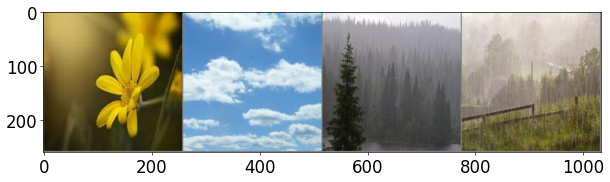

In [22]:
iterator = iter(train_dataloader)
imgs, labels = next(iterator)
out = make_grid(imgs[:4])
imshow(out)

In [23]:
print([class_names[labels[i].item()] for i in range(4)])

['Shine', 'Cloudy', 'Rain', 'Rain']


# **2. 다양한 모델 만들기**

In [24]:
# 단일 선형 계층
# (256 * 256 * 3 + 1) * 4 = 786,436
class Model1(nn.Module):
    def __init__(self):
        super(Model1, self).__init__()
        self.linear1 = nn.Linear(256*256*3, 4)
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = self.flatten(x)
        x = self.linear1(x)
        return x

### ※ nn.Module 상속

- 모델 구성 요소 관리: 레이어와 파라미터를 자동으로 관리.
- 순전파(Forward) 정의: forward() 메서드를 통해 간단하고 일관된 순전파 과정 정의.
- 계층적 설계: 서브모듈을 활용해 복잡한 모델을 쉽게 설계.
- 유틸리티 제공: 파라미터 저장/로드, 학습/추론 모드 전환 등 다양한 기능 제공.
- PyTorch 호환성: 최적화, 데이터 로더 등 PyTorch의 다른 기능과 손쉽게 통합.
- 추상화: 저수준 작업을 추상화하여 개발자의 생산성을 향상.

In [25]:
def train():
    start_time = time.time()
    print(f'[Epoch: {epoch + 1} - Training]')
    model.train()
    total = 0
    running_loss = 0.0
    running_corrects = 0

    for i, batch in enumerate(train_dataloader):
        imgs, labels = batch
        imgs, labels = imgs.cuda(), labels.cuda()
        outputs = model(imgs)
        optimizer.zero_grad()
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total += labels.shape[0]
        running_loss += loss.item()
        running_corrects += torch.sum(preds == labels.data)
        if i % log_step == 0:
            print(f'[batch: {i + 1}] running train loss: {running_loss / total}, running train accuracy: {running_corrects / total}')

    print(f'train loss: {running_loss / total}, accuracy: {running_corrects / total}')
    print("elapsed time: ", time.time() - start_time)
    return running_loss / total, (running_corrects / total).item()

In [26]:
def validate():
    start_time = time.time()
    print(f'[Epoch: {epoch + 1} - Validation]')
    model.eval()
    total = 0
    running_loss = 0.0
    running_corrects = 0

    for i, batch in enumerate(val_dataloader):
        imgs, labels = batch
        imgs, labels = imgs.cuda(), labels.cuda()
        with torch.no_grad():
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
        total += labels.shape[0]
        running_loss += loss.item()
        running_corrects += torch.sum(preds == labels.data)

        if i % log_step == 0:
            print(f'[Batch: {i + 1}] running val loss: {running_loss / total}, running val accuracy: {running_corrects / total}')

    print(f'val loss: {running_loss / total}, accuracy: {running_corrects / total}')
    print("elapsed time:", time.time() - start_time)
    return running_loss / total, (running_corrects / total).item()

In [27]:
def test():
    start_time = time.time()
    print(f'[Test]')
    model.eval()
    total = 0
    running_loss = 0.0
    running_corrects = 0

    for i, batch in enumerate(test_dataloader):
        imgs, labels = batch
        imgs, labels = imgs.cuda(), labels.cuda()

        with torch.no_grad():
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

        total += labels.shape[0]
        running_loss += loss.item()
        running_corrects += torch.sum(preds == labels.data)

        if i % log_step == 0:
            print(f'[Batch: {i + 1}] running test loss: {running_loss / total}, running test accuracy: {running_corrects / total}')

    print(f'test loss: {running_loss / total}, accuracy: {running_corrects / total}')
    print("elapsed time:", time.time() - start_time)
    return running_loss / total, (running_corrects / total).item()

In [28]:
def adjust_learning_rate(optimizer, epoch):
    lr = learning_rate
    if epoch >= 3:
        lr /= 10
    if epoch >= 7:
        lr /= 10
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

In [31]:
learning_rate = 0.01
log_step = 8

model = Model1()
model = model.cuda()

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

num_epochs = 20
best_val_acc = 0
best_epoch = 0

In [32]:
history = []
accuracy = []

os.makedirs("weights/Model1", exist_ok=True)

In [33]:
for epoch in range(num_epochs):
    adjust_learning_rate(optimizer, epoch)
    train_loss, train_acc = train()
    val_loss, val_acc = validate()
    history.append((train_loss, val_loss))
    accuracy.append((train_acc, val_acc))

    if val_acc > best_val_acc:
        print("[Info] best validation accuracy!")
        best_val_acc = val_acc
        best_epoch = epoch
        torch.save(model.state_dict(), f"weights/Model1/best_checkpoint_epoch_{epoch + 1}.pth")

torch.save(model.state_dict(), f"weights/Model1/last_checkpoint_epoch_{num_epochs}.pth")

[Epoch: 1 - Training]
[batch: 1] running train loss: 0.018597444519400597, running train accuracy: 0.484375
[batch: 9] running train loss: 0.20650644496911102, running train accuracy: 0.6267361044883728
train loss: 0.24932218874611675, accuracy: 0.6272600889205933
elapsed time:  6.637326955795288
[Epoch: 1 - Validation]
[Batch: 1] running val loss: 0.35215163230895996, running val accuracy: 0.640625
val loss: 0.3363683276706272, accuracy: 0.6777777671813965
elapsed time: 1.2628133296966553
[Info] best validation accuracy!
[Epoch: 2 - Training]
[batch: 1] running train loss: 0.37323397397994995, running train accuracy: 0.6875
[batch: 9] running train loss: 0.32214569052060443, running train accuracy: 0.6979166865348816
train loss: 0.32044505045045896, accuracy: 0.6954103112220764
elapsed time:  4.772815704345703
[Epoch: 2 - Validation]
[Batch: 1] running val loss: 0.3697485327720642, running val accuracy: 0.65625
val loss: 0.43576635784573026, accuracy: 0.644444465637207
elapsed time: 1

[Test]
[Batch: 1] running test loss: 0.18310511112213135, running test accuracy: 0.640625
test loss: 0.16736354237109158, accuracy: 0.747787594795227
elapsed time: 2.4891722202301025
Test loss: 0.16736354
Test accuracy: 74.78%


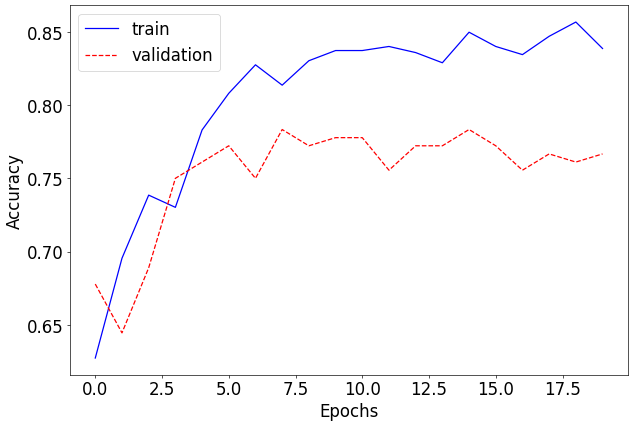

In [34]:
plt.plot([x[0] for x in accuracy], 'b', label='train')
plt.plot([x[1] for x in accuracy], 'r--',label='validation')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

test_loss, test_accuracy = test()
print(f"Test loss: {test_loss:.8f}")
print(f"Test accuracy: {test_accuracy * 100.:.2f}%")

In [35]:
# 두 개의 선형 계층을 사용하여 입력 데이터를 단계적으로 압축
# (256 * 256 * 3 + 1) * 64 + (64 + 1) * 4 = 12,583,236
class Model2(nn.Module):
    def __init__(self):
        super(Model2, self).__init__()
        self.linear1 = nn.Linear(256 * 256 * 3, 64)
        self.linear2 = nn.Linear(64, 4)
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = self.flatten(x)
        x = self.linear1(x)
        x = self.linear2(x)
        return x

[Epoch: 1 - Training]
[batch: 1] running train loss: 0.02205294743180275, running train accuracy: 0.1875
[batch: 9] running train loss: 0.0944750424888399, running train accuracy: 0.5555555820465088
train loss: 0.1049489557162777, accuracy: 0.5465924739837646
elapsed time:  5.379878044128418
[Epoch: 1 - Validation]
[Batch: 1] running val loss: 0.17107456922531128, running val accuracy: 0.40625
val loss: 0.16911077499389648, accuracy: 0.4555555582046509
elapsed time: 1.6339714527130127
[Info] best validation accuracy!
[Epoch: 2 - Training]
[batch: 1] running train loss: 0.13381275534629822, running train accuracy: 0.5625
[batch: 9] running train loss: 0.08339674977792634, running train accuracy: 0.5572916865348816
train loss: 0.0975757497408128, accuracy: 0.5646731853485107
elapsed time:  5.138472318649292
[Epoch: 2 - Validation]
[Batch: 1] running val loss: 0.10198841989040375, running val accuracy: 0.609375
val loss: 0.1044362465540568, accuracy: 0.6166666746139526
elapsed time: 1.268

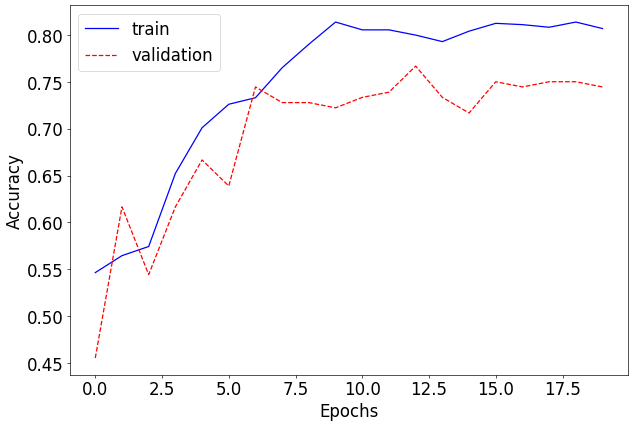

In [36]:
os.makedirs("weights/Model2", exist_ok=True)

learning_rate = 0.01
log_step = 8

model = Model2()
model = model.cuda()

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

num_epochs = 20
best_val_acc = 0
best_epoch = 0

history = []
accuracy = []

for epoch in range(num_epochs):
    adjust_learning_rate(optimizer, epoch)
    train_loss, train_acc = train()
    val_loss, val_acc = validate()
    history.append((train_loss, val_loss))
    accuracy.append((train_acc, val_acc))

    if val_acc > best_val_acc:
        print("[Info] best validation accuracy!")
        best_val_acc = val_acc
        best_epoch = epoch
        torch.save(model.state_dict(), f"weights/Model2/best_checkpoint_epoch_{epoch + 1}.pth")

torch.save(model.state_dict(), f"weights/Model2/last_checkpoint_epoch_{num_epochs}.pth")

plt.plot([x[0] for x in accuracy], 'b', label='train')
plt.plot([x[1] for x in accuracy], 'r--',label='validation')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

test_loss, test_accuracy = test()
print(f"Test loss: {test_loss:.8f}")
print(f"Test accuracy: {test_accuracy * 100.:.2f}%")

In [37]:
# (256*256*3+1)*128 + (128+1)*64 + (64+1)*32 + (32+1)*4 = 25176420
class Model3(nn.Module):
    def __init__(self):
        super(Model3, self).__init__()
        self.linear1 = nn.Linear(256 * 256 * 3, 128)
        self.dropout1 = nn.Dropout(0.5)
        self.linear2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(0.5)
        self.linear3 = nn.Linear(64, 32)
        self.dropout3 = nn.Dropout(0.5)
        self.linear4 = nn.Linear(32, 4)
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.linear1(x))
        x = self.dropout1(x)
        x = F.relu(self.linear2(x))
        x = self.dropout2(x)
        x = F.relu(self.linear3(x))
        x = self.dropout3(x)
        x = self.linear4(x)
        return x

[Epoch: 1 - Training]
[batch: 1] running train loss: 0.022242851555347443, running train accuracy: 0.15625
train loss: 0.02086146352022513, accuracy: 0.36439499258995056
elapsed time:  5.8529534339904785
[Epoch: 1 - Validation]
[Batch: 1] running val loss: 0.014514438807964325, running val accuracy: 0.5
val loss: 0.015396328104866876, accuracy: 0.5222222208976746
elapsed time: 1.8399343490600586
[Info] best validation accuracy!
[Epoch: 2 - Training]
[batch: 1] running train loss: 0.01833421364426613, running train accuracy: 0.4375
train loss: 0.018034247596008555, accuracy: 0.510431170463562
elapsed time:  4.86257266998291
[Epoch: 2 - Validation]
[Batch: 1] running val loss: 0.01371159590780735, running val accuracy: 0.53125
val loss: 0.013097784916559855, accuracy: 0.5944444537162781
elapsed time: 1.2699592113494873
[Info] best validation accuracy!
[Epoch: 3 - Training]
[batch: 1] running train loss: 0.012621978297829628, running train accuracy: 0.65625
train loss: 0.01591552530774155

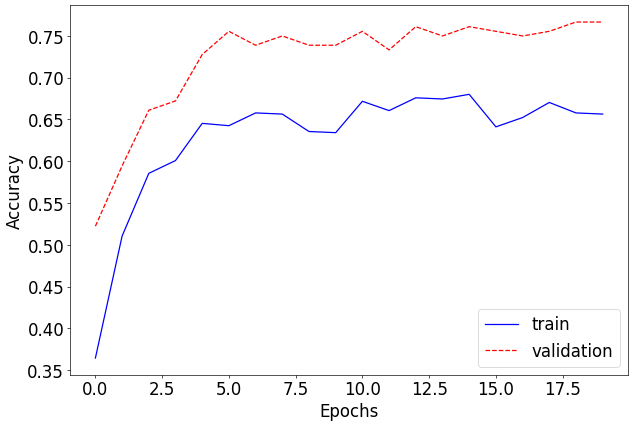

In [38]:
os.makedirs("weights/Model3", exist_ok=True)

learning_rate = 0.01
log_step = 20

model = Model3()
model = model.cuda()

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

num_epochs = 20
best_val_acc = 0
best_epoch = 0

history = []
accuracy = []

for epoch in range(num_epochs):
    adjust_learning_rate(optimizer, epoch)
    train_loss, train_acc = train()
    val_loss, val_acc = validate()
    history.append((train_loss, val_loss))
    accuracy.append((train_acc, val_acc))

    if val_acc > best_val_acc:
        print("[Info] best validation accuracy!")
        best_val_acc = val_acc
        best_epoch = epoch
        torch.save(model.state_dict(), f"weights/Model3/best_checkpoint_epoch_{epoch + 1}.pth")

torch.save(model.state_dict(), f"weights/Model3/last_checkpoint_epoch_{num_epochs}.pth")

plt.plot([x[0] for x in accuracy], 'b', label='train')
plt.plot([x[1] for x in accuracy], 'r--',label='validation')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

test_loss, test_accuracy = test()
print(f"Test loss: {test_loss:.8f}")
print(f"Test accuracy: {test_accuracy * 100.:.2f}%")